# Sleep and the Allocation of Time: Data Wrangling
In this notebook, we focus on the data wrangling and cleaning phase of the "Sleep and the Allocation of Time" dataset. 
The target response variable for the eventual statistical model is sleep data including naps (`slpnaps` in the original data).

## Data Variables and Renaming
The original dataset variables have somewhat cryptic names. We will rename them for clarity.
- `age`: `age` (in years)
- `black`: `is_black` (=1 if black)
- `case`: `case_id` (identifier)
- `clerical`: `is_clerical` (=1 if clerical worker)
- `construc`: `is_construction` (=1 if construction worker)
- `educ`: `education_years` (years of schooling)
- `earns74`: `earnings_1974` (total earnings, 1974)
- `gdhlth`: `is_good_health` (=1 if in good or excellent health)
- `inlf`: `in_labor_force` (=1 if in labor force)
- `leis1`: `leisure_sleep` (sleep - totwrk)
- `leis2`: `leisure_slpnaps` (slpnaps - totwrk)
- `leis3`: `leisure_rlxall` (rlxall - totwrk)
- `smsa`: `lives_in_smsa` (= 1 if live in smsa)
- `lhrwage`: `log_hourly_wage` (log hourly wage)
- `lothinc`: `log_other_income` (log othinc, unless othinc < 0)
- `male`: `is_male` (= 1 if male)
- `marr`: `is_married` (= 1 if married)
- `prot`: `is_protestant` (= 1 if Protestant)
- `rlxall`: `relax_all` (slpnaps + personal activs)
- `selfe`: `is_self_employed` (=1 if self employed)
- `sleep`: `sleep_mins` (mins sleep at night, per week)
- `slpnaps`: `sleep_naps_mins` (mins sleep, including naps, per week) **<- OUR TARGET**
- `south`: `lives_in_south` (=1 if live in south)
- `spsepay`: `spousal_income` (spousal wage income)
- `spwrk75`: `spouse_works` (=1 if spouse works)
- `totwrk`: `total_work_mins` (mins worked per week)
- `union`: `belongs_to_union` (=1 if belong to union)
- `worknrm`: `main_job_work_mins` (mins work main job)
- `workscnd`: `second_job_work_mins` (mins work second job)
- `exper`: `experience_years` (age - educ - 6)
- `yngkid`: `has_young_kid` (=1 if children < 3 present)
- `yrsmarr`: `years_married` (years married)
- `hrwage`: `hourly_wage` (hourly wage)
- `agesq`: `age_squared` (age^2)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import missingno as msno

# Set styling for plots
sns.set_theme(style="whitegrid", palette="muted")

## Data wrangling
We will load the Excel file and assign the original column names, then immediately rename them to our more descriptive names.

In [2]:
# Original columns based on the description file
orig_cols = [
    'age', 'black', 'case', 'clerical', 'construc', 'educ', 'earns74', 'gdhlth', 
    'inlf', 'leis1', 'leis2', 'leis3', 'smsa', 'lhrwage', 'lothinc', 'male', 
    'marr', 'prot', 'rlxall', 'selfe', 'sleep', 'slpnaps', 'south', 'spsepay', 
    'spwrk75', 'totwrk', 'union', 'worknrm', 'workscnd', 'exper', 'yngkid', 
    'yrsmarr', 'hrwage', 'agesq'
]

# Better column names
new_cols = [
    'age', 'is_black', 'case_id', 'is_clerical', 'is_construction', 'education_years', 
    'earnings_1974', 'is_good_health', 'in_labor_force', 'leisure_sleep', 'leisure_slpnaps', 
    'leisure_rlxall', 'lives_in_smsa', 'log_hourly_wage', 'log_other_income', 'is_male', 
    'is_married', 'is_protestant', 'relax_all', 'is_self_employed', 'sleep_mins', 
    'sleep_naps_mins', 'lives_in_south', 'spousal_income', 'spouse_works', 'total_work_mins', 
    'belongs_to_union', 'main_job_work_mins', 'second_job_work_mins', 'experience_years', 
    'has_young_kid', 'years_married', 'hourly_wage', 'age_squared'
]

# Load data without header and apply original columns
file_path = "data/assignment_data/sleep75.xls"
df = pd.read_excel(file_path, header=None, names=orig_cols)

# Rename to new descriptive names
df.columns = new_cols

df.head()

,age,is_black,case_id,is_clerical,is_construction,education_years,earnings_1974,is_good_health,in_labor_force,leisure_sleep,...,spouse_works,total_work_mins,belongs_to_union,main_job_work_mins,second_job_work_mins,experience_years,has_young_kid,years_married,hourly_wage,age_squared
0,32,0,1,0.0,0.0,12,0,0,1,3529,...,0,3438,0,3438,0,14,0,13,7.070004,1024
1,31,0,2,0.0,0.0,14,9500,1,1,2140,...,0,5020,0,5020,0,11,0,0,1.429999,961
2,44,0,3,0.0,0.0,17,42500,1,1,4595,...,1,2815,0,2815,0,21,0,0,20.53,1936
3,30,0,4,0.0,0.0,12,42500,1,1,3211,...,1,3786,0,3786,0,12,0,12,9.619998,900
4,64,0,5,0.0,0.0,14,2500,1,1,4052,...,1,2580,0,2580,0,44,0,33,2.75,4096


### Missing values detection and cleaning

In [3]:
df = df.replace('.', np.nan)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 706 entries, 0 to 705
Data columns (total 34 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   706 non-null    int64  
 1   is_black              706 non-null    int64  
 2   case_id               706 non-null    int64  
 3   is_clerical           706 non-null    float64
 4   is_construction       706 non-null    float64
 5   education_years       706 non-null    int64  
 6   earnings_1974         706 non-null    int64  
 7   is_good_health        706 non-null    int64  
 8   in_labor_force        706 non-null    int64  
 9   leisure_sleep         706 non-null    int64  
 10  leisure_slpnaps       706 non-null    int64  
 11  leisure_rlxall        706 non-null    int64  
 12  lives_in_smsa         706 non-null    int64  
 13  log_hourly_wage       532 non-null    object 
 14  log_other_income      706 non-null    float64
 15  is_male               706 non-null

In [4]:
# Check missing values
missing_data = df.isna().sum()
missing_data[missing_data > 0]

log_hourly_wage    174
hourly_wage        174
dtype: int64

### Finding the reason for missing data

In [ ]:
# Filter the dataframe to keep only the rows where 'is_clerical' is NOT 0 and NOT 1
weird_rows = df[~df['is_clerical'].isin([0, 1])]
weird_rows[['case_id', 'is_clerical', 'is_construction', 'in_labor_force', 'hourly_wage']].head(10)

,case_id,is_clerical,is_construction,in_labor_force,hourly_wage
532,533,0.182331,0.030075,0,NaN
533,534,0.182331,0.030075,0,NaN
534,535,0.182331,0.030075,0,NaN
535,536,0.182331,0.030075,0,NaN
536,537,0.182331,0.030075,0,NaN
537,538,0.182331,0.030075,0,NaN
538,539,0.182331,0.030075,0,NaN
539,540,0.182331,0.030075,0,NaN
540,541,0.182331,0.030075,0,NaN
541,542,0.182331,0.030075,0,NaN


For the variables `is_clerical` and `is_construction` (which should be strictly 0 or 1), respondents at the very end of the file have values of `0.182331` and `0.030075`. 

It might suggest that the original authors had missing values for these individuals and decided to use **mean imputation** (filling in the sample average).

To fix this, we will revert these specific erroneous values back to `NaN` so we can impute them properly later.

In [6]:
df.loc[np.isclose(df['is_clerical'], 0.182331), 'is_clerical'] = np.nan
df.loc[np.isclose(df['is_construction'], 0.030075), 'is_construction'] = np.nan

<Axes: >

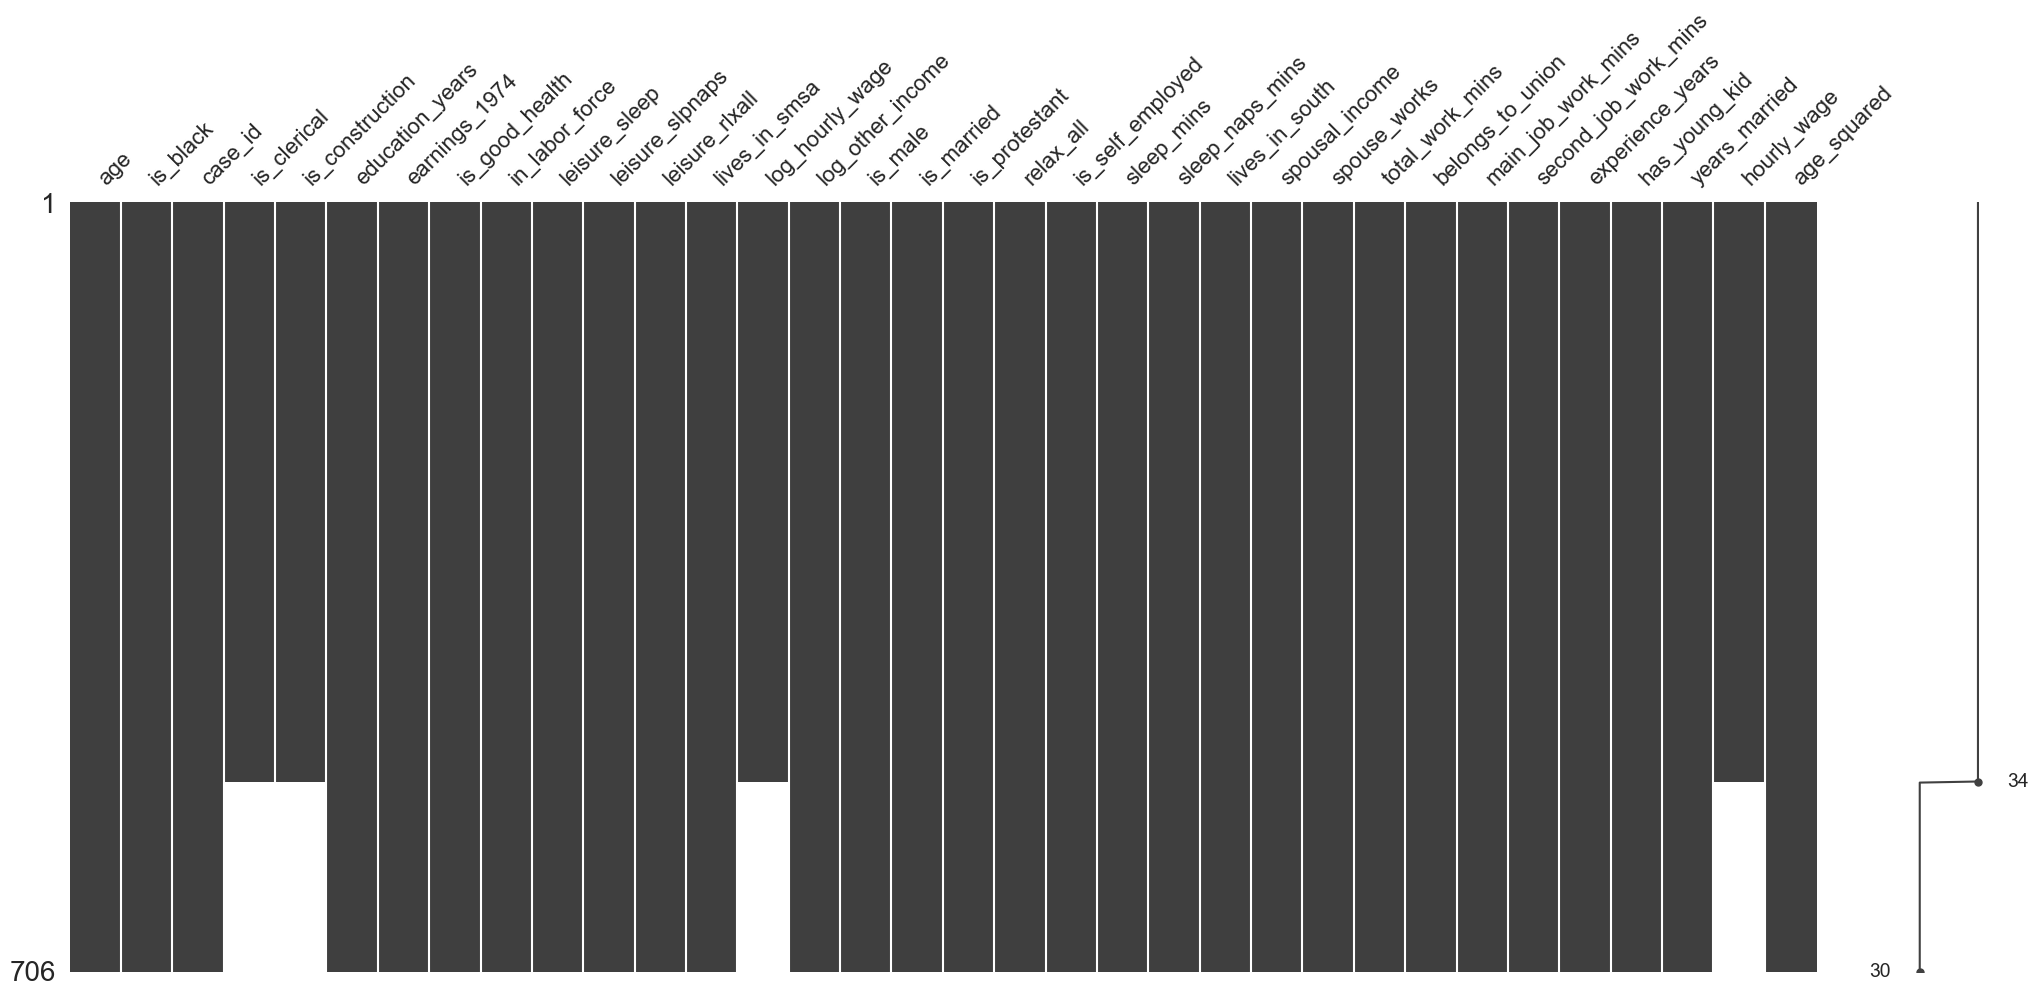

In [7]:
msno.matrix(df)

<Axes: >

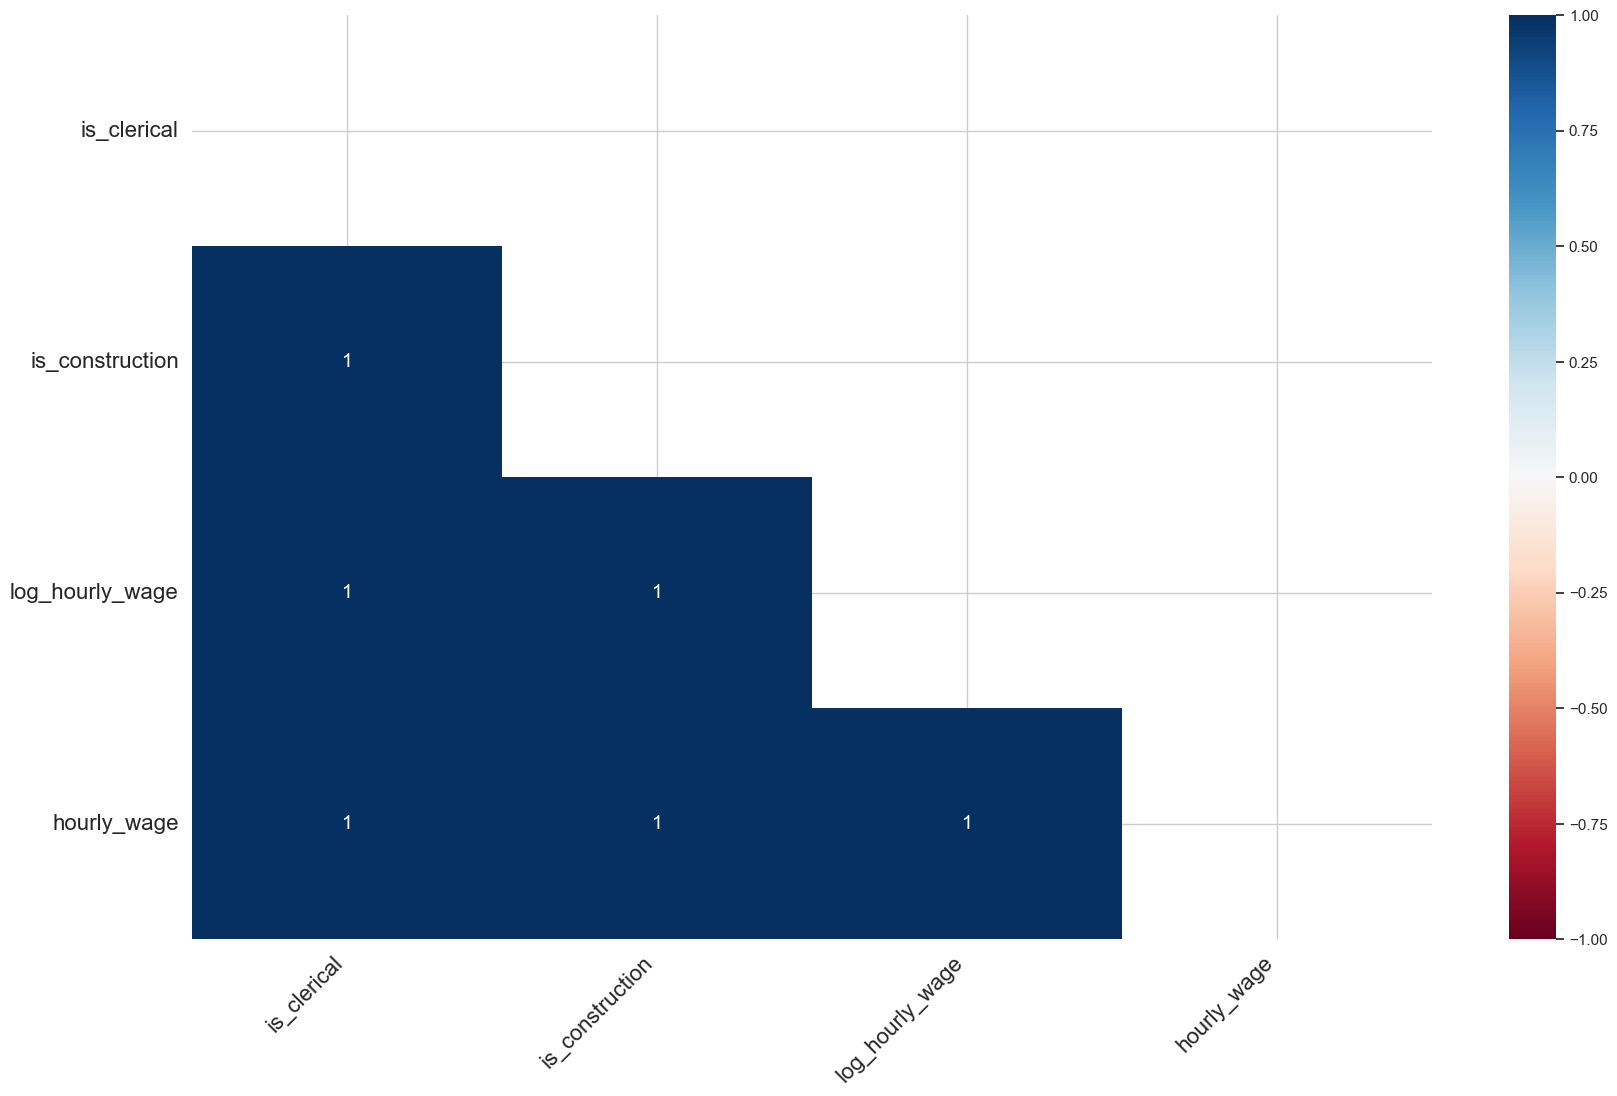

In [8]:
msno.heatmap(df)

The missing values in `hourly_wage` and `log_hourly_wage` (174 missing records) perfectly align with the 174 individuals who are not currently in the labor force (`in_labor_force` == 0).
What is more, individuals who do not work inherently do not earn an hourly wage, nor do they hold a specific labor occupation (missing data for `hourly_wage`, `log_hourly_wage`, `is_clerical`, `is_construction`).

**Missing At Random** (MAR): As visually proven by the missingno matrix, the missingness across wages and occupations occurs in perfect tandem. This data is "missing Not At Random" because the missingness is directly caused by another observed variable in the dataset (`in_labor_force`).

If we were to simply drop these 174 individuals from our econometric analysis, we would introduce severe *selection bias* into our sleep equation. People who do not participate in the labor force likely have fundamentally different time allocation and sleeping habits than those who do work full-time.

To resolve this and preserve our sample size, the best course of action is to implement Hot Deck Imputation.

This way, we can estimate what a non-working individual's potential wage offer and likely occupation would be, based on their closest peers in the dataset (matching on similar demographics `education_years`, `experience_years`, `age`, and `is_married`). Once the data is cleanly imputed, we can proceed to estimate our final multivariate regression model on the female subset without biased sample loss.

### Hot Deck Nearest Neighbor Imputation

In [9]:
feature_cols = [
    'age', 'age_squared', 'education_years', 'experience_years',
    'is_married', 'years_married', 'is_black', 'in_labor_force',
    'lives_in_smsa', 'lives_in_south', 'is_protestant',
    'has_young_kid', 'is_good_health', 'is_self_employed'
]

# Columns that need to be imputed
cols_to_impute = ['hourly_wage', 'is_clerical', 'is_construction']

working_cols = feature_cols + cols_to_impute
df_for_knn = df[working_cols].copy()

# KNN Imputation
imputer = KNNImputer(n_neighbors=5)
imputed_array = imputer.fit_transform(df_for_knn)
df_knn = pd.DataFrame(imputed_array, columns=working_cols, index=df.index)

# Write imputed values back into df
df['hourly_wage'] = df_knn['hourly_wage']

# Binary dummies must be rounded back to 0 or 1 after KNN averaging
df['is_clerical']    = df_knn['is_clerical'].round().astype(int)
df['is_construction'] = df_knn['is_construction'].round().astype(int)

# Recalculate log_hourly_wage from the imputed wage
df['log_hourly_wage'] = np.log(df['hourly_wage'])


print("Missing values after imputation:")
cols_check = ['hourly_wage', 'log_hourly_wage', 'is_clerical', 'is_construction']
print(df[cols_check].isna().sum())

Missing values after imputation:
hourly_wage        0
log_hourly_wage    0
is_clerical        0
is_construction    0
dtype: int64
